In [1]:
library(SPOTlight)
library(ggplot2)
library(Seurat)
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library(circlize)
library(RColorBrewer)

Le chargement a nécessité le package : SeuratObject

Le chargement a nécessité le package : sp


Attachement du package : ‘SeuratObject’


L'objet suivant est masqué depuis ‘package:BiocGenerics’:

    intersect


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, t



Attachement du package : ‘dplyr’


L'objet suivant est masqué depuis ‘package:Biobase’:

    combine


Les objets suivants sont masqués depuis ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union


Le chargement a nécessité le package : grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one

In [ ]:
options(repr.plot.width = 48, repr.plot.height = 24, repr.plot.pointsize = 24)

In [3]:
CARD_obj <- readRDS("/home/adufour/work/rds_storage/epilepsie/card_deconv.rds")

In [4]:
load("/work/project/fragencode/workspace/umr_1141/results/epilepsie/spatial/seurat_obj/whole_clustering_subclustering_Seurat_objects.RData")

In [35]:
plotSpatialScatterpie <- function(
    x,
    y,
    cell_types = colnames(y),
    img = FALSE,
    slice = NULL,
    scatterpie_alpha = 1,
    pie_scale = 0.4,
    degrees = NULL,
    axis = NULL,
    ...) {
    # Check necessary packages are installed and if not STOP

    # Class checks
    stopifnot(
        # Check x inputs
        is.matrix(x) | is.data.frame(x) |
            is(x, "Seurat") | is(x, "SpatialExperiment"),
        # Check y inputs
        is.matrix(y) | is.data.frame(y),
        # cell_types needs to be a character with max length = ncol(y)
        is.character(cell_types) & length(cell_types) <= ncol(y),
        # Check img
        # img not checked since its checked in plotImage()
        # Check slice name
        is.character(slice) | is.null(slice),
        # Check plotting parameters are numeric
        is.numeric(scatterpie_alpha),
        is.numeric(pie_scale),
        is.numeric(degrees) | is.null(degrees),
        axis %in% c("h", "v") | is.null(axis)
    )

    # If image is passed add it as the base layer, if not, no image
    # Need to use isFALSE bc img can have many different inputs
    # Set ymax to overlap image and piecharts
    if (isFALSE(img)) {
        p <- ggplot() +
            coord_fixed()
        ymax <- 0
    } else {
        # Extract image from Seurat or SE objects when img is TRUE
        # If image is not TRUE and not FALSE an acceptable class for plotImage
        # has been passed
        if (is(x, "Seurat") | is(x, "SpatialExperiment") & isTRUE(img)) {
            img <- extract_image(x, slice)

            # Rotate or mirror image if dots don't overlay properly
            if (is(x, "SpatialExperiment")) {

                ## Rotate image if needed
                if (!is.null(degrees)) {
                    img <- SpatialExperiment::SpatialImage(
                        grDevices::as.raster(img))
                    img <- as(img, "LoadedSpatialImage")
                    img <- SpatialExperiment::rotateImg(img, degrees = degrees)
                    img <- grDevices::as.raster(img)
                }

                ## Make mirror image if necessary
                if (!is.null(axis)) {
                    img <- SpatialExperiment::SpatialImage(
                        grDevices::as.raster(img))
                    img <- as(img, "LoadedSpatialImage")
                    img <- SpatialExperiment::mirrorImg(img, axis = axis)
                    img <- grDevices::as.raster(img)
                }
            }
        }

        p <- plotImage(x = img)
        ymax <- max(p$coordinates$limits$y)
    }

    # Extract coordinate matrix from x
    if (!is.matrix(x))
        x <- .extract_coord(x = x, slice = slice, img = img)

    # Check colnames
    x <- .x_cnames(x)

    # Convert y to matrix format
    if (!is.matrix(x)) {
        y <- as.matrix(x)
    }

    # Stop if x and y don't have the same number of columns or if the
    # rownames are not common between them
    stopifnot(
        nrow(x) == nrow(y),
        all(rownames(x) %in% rownames(y)))

    # merge by row names (by=0 or by="row.names")
    df <- merge(x, y, by = 0, all = TRUE)
    # make y negative
    df$coord_y_i <- abs(df$coord_y - ymax)

    # Plot
    p + scatterpie::geom_scatterpie(
        data = df,
        aes_string(
            x = "coord_x",
            y = "coord_y_i"
        ),
        cols = cell_types,
        color = NA,
        alpha = scatterpie_alpha,
        pie_scale = pie_scale,
        ...) +
        scale_fill_manual(
            values = colors_dutch90
        ) +
        # Below not needed bc comes from plotImage
        # coord_fixed() +
        theme_void() +
        theme(legend.key.size = unit(4, "lines"),
             legend.text=element_text(size=24))
    }

.x_cnames <- function(x) {
    # If the column names of x aren't right fix them
    cnames <- c("coord_y", "coord_x")
    if (!all(colnames(x) %in% cnames)) {
        colnames(x) <- cnames
    }
    x
}

# Coordinates and return a matrix object where each row is a spot and the
# columns are the x and y coordinates
.extract_coord <- function(x, slice, img) {
    # Iterate over all the accepted classes and return spot coordinates
    if (is.data.frame(x)) {
        # Convert to matrix
        x <- as.matrix(x)
    } else if (is(x, "Seurat")) {
        # Stop if there are no images or the name selected doesn't exist
        stopifnot(
            # Stop if there are no images
            !is.null(SeuratObject::Images(x)),
            # Stop if the image doesn't exist
            is.null(slice) | slice %in% SeuratObject::Images(x))

        # If image is null use the first slice
        if (is.null(slice))
            slice <- SeuratObject::Images(x)[1]

        # Extract spatial coordinates
        x <- as.matrix(SeuratObject::GetTissueCoordinates(x, image = slice))
    } else if (is(x, "SpatialExperiment")) {

        # Stop if there are no images or the name selected doesn't exist
        stopifnot(
            # Stop if there are no images
            !is.null(SpatialExperiment::getImg(x)),
            # Stop if the image doesn't exist
            slice %in% SpatialExperiment::imgData(x)[1, "sample_id"],
            # Return error if there are no colnames in the object
            !is.null(colnames(x))
        )

        # If slice is null use the first slice
        img_df <- SpatialExperiment::imgData(x)
        if (is.null(slice))
            slice <- img_df[1, "sample_id"]

        # Scale factor to scale the coordinates
        sf <- img_df[img_df$sample_id == slice, "scaleFactor"]

        ## Extract spot barcodes
        barcodes <- colnames(x)

        ## Extract spatial coordinates
        # coord_df <- SpatialExperiment::spatialCoords(x)
        x <- as.matrix(SpatialExperiment::spatialCoords(x)[, c(1, 2)])

        ## Scale coordinates
        x <- x * sf

        ## Add barcodes to coord matrix & change colnames
        rownames(x) <- barcodes
    } else {
        stop("Couldn't extract image coordinates.
            Please check class(x) is SpatialExperiment, Seurat,
            dataframe or matrix")
    }
    return(x)

}

In [36]:
extract_image <- function(x, slice = NULL) {
    # Iterate over all the accepted classes and convert the image to array
    if (is.character(x)) {
        
        # Check if the file exists
        stopifnot(file.exists(x))
        
        # Check the file is in the right format
        typ <- c("jpg", "jpeg", "png")
        pat <- paste0(".", typ, "$")
        idx <- vapply(pat, grepl, x = x, logical(1), ignore.case = TRUE)
        if (!any(idx)) {
            stop("'x' should be of file type JPG, JPEG or PNG")
        }
        
        # Read file
        x <- switch(typ[idx],
            png = png::readPNG(x),
            jpeg::readJPEG(x))
        
    } else if (is(x, "Seurat")) {
        # Stop if there are no images or the name selected doesn't exist
        stopifnot(
            !is.null(SeuratObject::Images(x)),
            slice %in% SeuratObject::Images(x))
        
        # If image is null use the first slice
        if (is.null(slice)) 
            slice <- SeuratObject::Images(x)[1]
        
        # Extract Image in raster format
        x <- SeuratObject::GetImage(x, image = slice, mode = "raster")
        # Conver to matrix
        x <- as.matrix(x)
        
    } else if (is(x, "SpatialExperiment")) {
        
        # Stop if there are no images or the name selected doesn't exist
        stopifnot(
            !is.null(SpatialExperiment::getImg(x)),
            slice %in% SpatialExperiment::imgData(x)[1, "sample_id"]
        )
        
        # If image is null use the first slice
        if (is.null(slice)) 
            slice <- SpatialExperiment::imgData(x)[1, "sample_id"]
        
        # Convert to raster
        x <- SpatialExperiment::imgRaster(x, sample_id = slice)
        x <- as.matrix(x)
    } else {
        stop("Couldn't extract image, See ?plotImage for valid image inputs.")
    }
    return(x)
}

In [5]:
proportion <- CARD_obj@Proportion_CARD

In [6]:
new_proportions <- data.frame(
Neuroblasts_radial_glial_like_cells = rowSums(proportion[,c("Neuroblasts, olfactory", "Neuroblast-like, habenula", "Neuroblasts, olfactory bulb", "Neuroblasts, cerebellum", "Neuroblasts, septum","Granule neuroblasts, dentate gyrus","Neuronal intermidate progenitor cells","Dentate gyrus radial glia-like cells", "Subventricular zone radial glia-like cells")]),
Inhibitory_neurons = rowSums(proportion[,c("Inhibitory neurons, thalamus","Inhibitory neurons, pallidum","Inhibitory neurons, septal nucleus","Inhibitory neurons, hypothalamus", "Inhibitory neurons, spinal cord", "Inhibitory neurons, hindbrain", "Inhibitory neurons, midbrain", "Inhibitory neurons, telencephalon","Basket and bistratified cells, cortex/hippocampus","Trilaminar cells, hippocampus","CGE-derived neurogliaform cells Cxcl14+, cortex/hippocampus", "CGE-derived neurogliaform cells, cortex/hippocampus", "Ivy and MGE-derived neurogliaform cells, cortex/hippocampus")]),
Medium_spiny_neurons_striatum = rowSums(proportion[,c("D1 medium spiny neurons, striatum", "D2 medium spiny neurons, striatum", "Patch D1/D2 neurons, striatum", "Matrix D1 neurons, striatum")]),
Cholinergic_neurons = rowSums(proportion[,c("Cholinergic neurons, midbrain red nucleus", "Cholinergic neurons, sympathetic", "Cholinergic neurons, habenula", "Cholinergic neurons, hindbrain", "Cholinergic neurons, septal nucleus, Meissnert and diagonal band","Cholinergic interneurons, telencephalon","Cholinergic enteric neurons", "Cholinergic enteric neurons, VGLUT2")]),
Excitatory_neurons_cerebral_cortex = proportion[,c("Excitatory neurons, cerebral cortex")],
Excitatory_neurons_hippocampus = rowSums(proportion[,c("Excitatory neurons, hippocampus CA3","Excitatory neurons, hippocampus CA1","Granule neurons, dentate gyrus")]),
Excitatory_neurons_other = rowSums(proportion[,c("Excitatory neurons, amygdala","Excitatory neurons, thalamus","Excitatory neurons, midbrain", "Excitatory neurons, spinal cord", "Purkinje cells", "Excitatory neurons, hindbrain", "Excitatory neurons, hypothalamus","Granular layer interneurons, cerebellum","Granule neurons, cerebellum")]),
Interneurons = rowSums(proportion[,c("Non-border Cck interneurons, cortex/hippocampus", "Non-border Cck interneurons, hippocampus", "Non-border Cck interneurons, cortex/hippocampus", "Non-border Cck interneurons, hippocampus", "R-LM border Cck interneurons, cortex/hippocampus", "Sleep-active, long-range projection interneurons, cortex/hippocampus", "Inhibitory interneurons, hippocampus", "Axo-axonic, cortex/hippocampus","Molecular layer interneurons, cerebellum", "External plexiform layer interneuron, olfactory bulb", "Dopaminergic periglomerular interneuron, olfactory bulb")]),
Other_neurons = rowSums(proportion[,c("Inhibitory neurons, olfactory bulb", "Noradrenergic erector muscle neurons", "Noradrenergic neurons, sympathetic", "Noradrenergic neurons of the medulla", "Dopaminergic neurons, periaqueductal grey", "Dopaminergic neurons, ventral midbrain (SNc, VTA)", "Glutamatergic projection neurons of the raphe nucleus", "Peptidergic neurons, hypothalamus", "Dopaminergic neurons, olfactory nulb", "Orexin-producing neurons, hypothalamus", "Pmch neurons, hypothalamus", "Serotonergic neurons, hindbrain", "Nitrergic enteric neurons", "Central canal neurons, spinal cord")]),
Telencephalon_astrocytes = rowSums(proportion[,c("Telencephalon astrocytes, fibrous", "Telencephalon astrocytes, protoplasmic")]),
Non_telencephalon_astrocytes = rowSums(proportion[,c("Non-telencephalon astrocytes, fibrous","Non-telencephalon astrocytes, protoplasmic")]),
Myoc_expressing_astrocyte_like = proportion[,c("Dorsal midbrain Myoc-expressing astrocyte-like")],
Mature_oligodendrocytes = rowSums(proportion[,c("Myelin forming oligodendrocytes (MFOL)", "Mature oligodendrocytes, spinal cord enriched (high Klk6)", "Mature oligodendrocytes, hindbrain", "Mature oligodendrocytes")]),
Newly_formed_committed_and_precursors_of_oligodendrocytes = rowSums(proportion[,c("Oligodendrocytes precursor cells","Newly formed oligodendrocytes (NFOL)", "Newly formed oligodendrocytes (NFOL), pons/medulla specific", "Committed oligodendrocytes cells (COP), pons/medulla specific", "Committed oligodendrocytes cells (COP)")]),
Microglia = proportion[,c("Microglia")],
Microglia_activated = proportion[,c("Microglia, activated")],
Perivascular_macrophages = rowSums(proportion[,c("Perivascular macrophages, activated", "Perivascular macrophages")]),
Pericytes_Vascular_cells = rowSums(proportion[,c("Vascular smooth muscle cells, arterial", "Vascular leptomeningeal cells", "Vascular endothelial cells, venous", "Vascular endothelial cells, capillary", "Vascular leptomeningeal cells", "Pericytes", "Pericytes, possibly mixed with VENC")]),
Ependymal_cells = rowSums(proportion[,c("Chorid plexus epithelial cells","Ependymal cells, midbrain", "Ependymal cells", "Ependymal cells, spinal cord","Hypendymal cell, subcommissural organ")]),
Other_cells = rowSums(proportion[,c("Inner horizontal cell, olfactory bulb", "Olfactory ensheathing cells", "Afferent nuclei of cranial nerves VI-XII", "Afferent nuclei of cranial nerves III-V", "Adrenergic cell groups of the medulla", "Oxytocin-producing cells, hypothalamus", "Vasopressin-producing cells, hypothalamus", "Satellite glia", "Satellite glia, proliferating", "Peptidergicv (PEP2), DRG", "Peptidergic (PEP1..4), DRG", "Peptidergic (PEP1.3), DRG", "Peptidergic (PEP1.1), DRG", "Peptidergic (PEP1.2), DRG", "Peptidergic (TrpM8), DRG", "Non-peptidergic (TH), DRG", "Non-peptidergic (NP1.2), DRG", "Non-peptidergic (NP1.1), DRG", "Non-peptidergic (NP2.2), DRG", "Non-peptidergic (NP2.1), DRG", "Non-peptidergic (NP3), DRG", "Neurofilament (NF4/5), DRG", "Neurofilament (NF2/3), DRG", "Neurofilament (NF1), DRG", "Schwann cells","Enteric mesothelial fibroblasts","Enteric glia, proliferating", "Enteric glia", "Bergmann glia","Cajal-Retzius cells, hippocampus","Olfactory astrocytes")])
)

In [7]:
# Liste de tes échantillons
samples <- c("A_L1_S1","A_L2_S5","A_L3_S9","A_L4_S13",
             "B_L1_S2","B_L2_S6","B_L3_S10","B_L4_S14",
             "C_L1_S3","C_L2_S7","C_L3_S11","C_L4_S15",
             "D_L1_S4","D_L2_S8","D_L3_S12","D_L4_S16")

# Calcul des proportions par cluster pour chaque échantillon
table_class_by_clusters <- sapply(samples, function(samp) {
  rows <- rownames(seurat_object_whole_clustering@meta.data[
    seurat_object_whole_clustering@meta.data$orig.ident == samp, ])
  colSums(new_proportions[rows, ])
})

# Mise en forme en data.frame transposé (comme ton code initial)
table_class_by_clusters <- as.data.frame(t(table_class_by_clusters))

In [49]:
# Mise en forme en data.frame transposé (comme ton code initial)
write.csv(table_class_by_clusters, "/home/adufour/work/table/epilepsie/cell_proportion_2.csv")

In [8]:
seurat_object_whole_clustering@meta.data <- cbind(seurat_object_whole_clustering@meta.data, new_proportions)

In [ ]:
for(i in colnames(new_proportions)){
    plot_spatial <- SpatialFeaturePlot(seurat_object_whole_clustering,
                   pt.size.factor = 30,
                   features = i,
                   keep.scale = "all",
                   images = c('A_L1_S1', 'A_L2_S5', 'C_L1_S3', 'C_L2_S7', 'B_L1_S2', 'B_L2_S6', 'D_L1_S4', 'D_L2_S8', 'A_L3_S9', 'A_L4_S13', 'C_L4_S15', 'C_L3_S11', 'B_L3_S10', 'B_L4_S14', 'D_L4_S16', 'D_L3_S12'),
                   ncol = 4)
    ggsave(
      paste0('/home/adufour/work/plots/epilepsie/', i, '_cell_type_cell_repartition.svg'),
      plot_spatial,
      height = 18,
      width = 20
    )
}

In [7]:
# Liste de tes échantillons
samples <- c("A_L1_S1","A_L2_S5","A_L3_S9","A_L4_S13",
             "B_L1_S2","B_L2_S6","B_L3_S10","B_L4_S14",
             "C_L1_S3","C_L2_S7","C_L3_S11","C_L4_S15",
             "D_L1_S4","D_L2_S8","D_L3_S12","D_L4_S16")

list_samples <- list(EPI_D5 = c("A_L1_S1","A_L3_S9"),
                     EPI_D10 = c("A_L2_S5","A_L4_S13"),
                     EPI_D20 = c("C_L1_S3","C_L4_S15"),
                     EPI_D40 = c("C_L2_S7","C_L3_S11"),
                     CTRL_D5 = c("B_L1_S2","B_L3_S10"),
                     CTRL_D10 = c("B_L2_S6","B_L4_S14"),
                     CTRL_D20 = c("D_L1_S4","D_L4_S16"),
                     CTRL_D40 = c("D_L2_S8","D_L3_S12"))

# Calcul des proportions par cluster pour chaque échantillon
table_class_by_clusters <- sapply(list_samples, function(samp) {
  rows <- rownames(seurat_object_whole_clustering@meta.data[seurat_object_whole_clustering@meta.data$orig.ident %in% samp, ])
  colSums(new_proportions[rows, ])
})

# Mise en forme en data.frame transposé (comme ton code initial)
table_class_by_clusters <- as.data.frame(t(table_class_by_clusters))

In [8]:
result <- data.frame() # Initialisation vide

for (i in colnames(table_class_by_clusters)) {
    # Vérifie que la colonne est numérique
    if (is.numeric(table_class_by_clusters[[i]])) {
        z_test_5 <- prop.test(x = c(table_class_by_clusters["EPI_D5", i], table_class_by_clusters["CTRL_D5", i]), 
                            n = c(sum(table_class_by_clusters["EPI_D5",]), sum(table_class_by_clusters["CTRL_D5",])))
        z_test_10 <- prop.test(x = c(table_class_by_clusters["EPI_D10", i], table_class_by_clusters["CTRL_D10", i]), 
                            n = c(sum(table_class_by_clusters["EPI_D10",]), sum(table_class_by_clusters["CTRL_D10",])))
        z_test_20 <- prop.test(x = c(table_class_by_clusters["EPI_D20", i], table_class_by_clusters["CTRL_D20", i]), 
                            n = c(sum(table_class_by_clusters["EPI_D20",]), sum(table_class_by_clusters["CTRL_D20",])))
        z_test_40 <- prop.test(x = c(table_class_by_clusters["EPI_D40", i], table_class_by_clusters["CTRL_D40", i]), 
                            n = c(sum(table_class_by_clusters["EPI_D40",]), sum(table_class_by_clusters["CTRL_D40",])))
        res_tab <- data.frame(row.names = i,
                              D5 = -log(z_test_5[["p.value"]]),
                              D10 = -log(z_test_10[["p.value"]]),
                              D20 = -log(z_test_20[["p.value"]]),
                              D40 = -log(z_test_40[["p.value"]]))
        result <- rbind(result, res_tab)
    }
}

In [43]:
result_FC <- data.frame() # Initialisation vide

for (i in colnames(table_class_by_clusters)) {
    # Vérifie que la colonne est numérique
    if (is.numeric(table_class_by_clusters[[i]])) {
        z_test_5 <- table_class_by_clusters["EPI_D5", i]/table_class_by_clusters["CTRL_D5", i]
        z_test_10 <- table_class_by_clusters["EPI_D10", i]/table_class_by_clusters["CTRL_D10", i]
        z_test_20 <- table_class_by_clusters["EPI_D20", i]/table_class_by_clusters["CTRL_D20", i]
        z_test_40 <- table_class_by_clusters["EPI_D40", i]/table_class_by_clusters["CTRL_D40", i]
        res_tab <- data.frame(row.names = i,
                              D5 = log(z_test_5),
                              D10 = log(z_test_10),
                              D20 = log(z_test_20),
                              D40 = log(z_test_40))
        result_FC <- rbind(result_FC, res_tab)
    }
}

In [45]:
result_FC$terms <- rownames(result_FC)
result_FC <- result_FC %>%
  pivot_longer(
    cols = c(1:ncol(.)-1),
    names_to = 'time'
  ) %>%
  dplyr::rename(FC = value) %>%
  mutate(id_to_merge = paste0(terms, '_', time))

In [46]:
result$terms <- rownames(result)
result <- result %>%
  pivot_longer(
    cols = c(1:ncol(.)-1),
    names_to = 'time'
  ) %>%
  dplyr::rename(p_value = value) %>%
  mutate(id_to_merge = paste0(terms, '_', time))

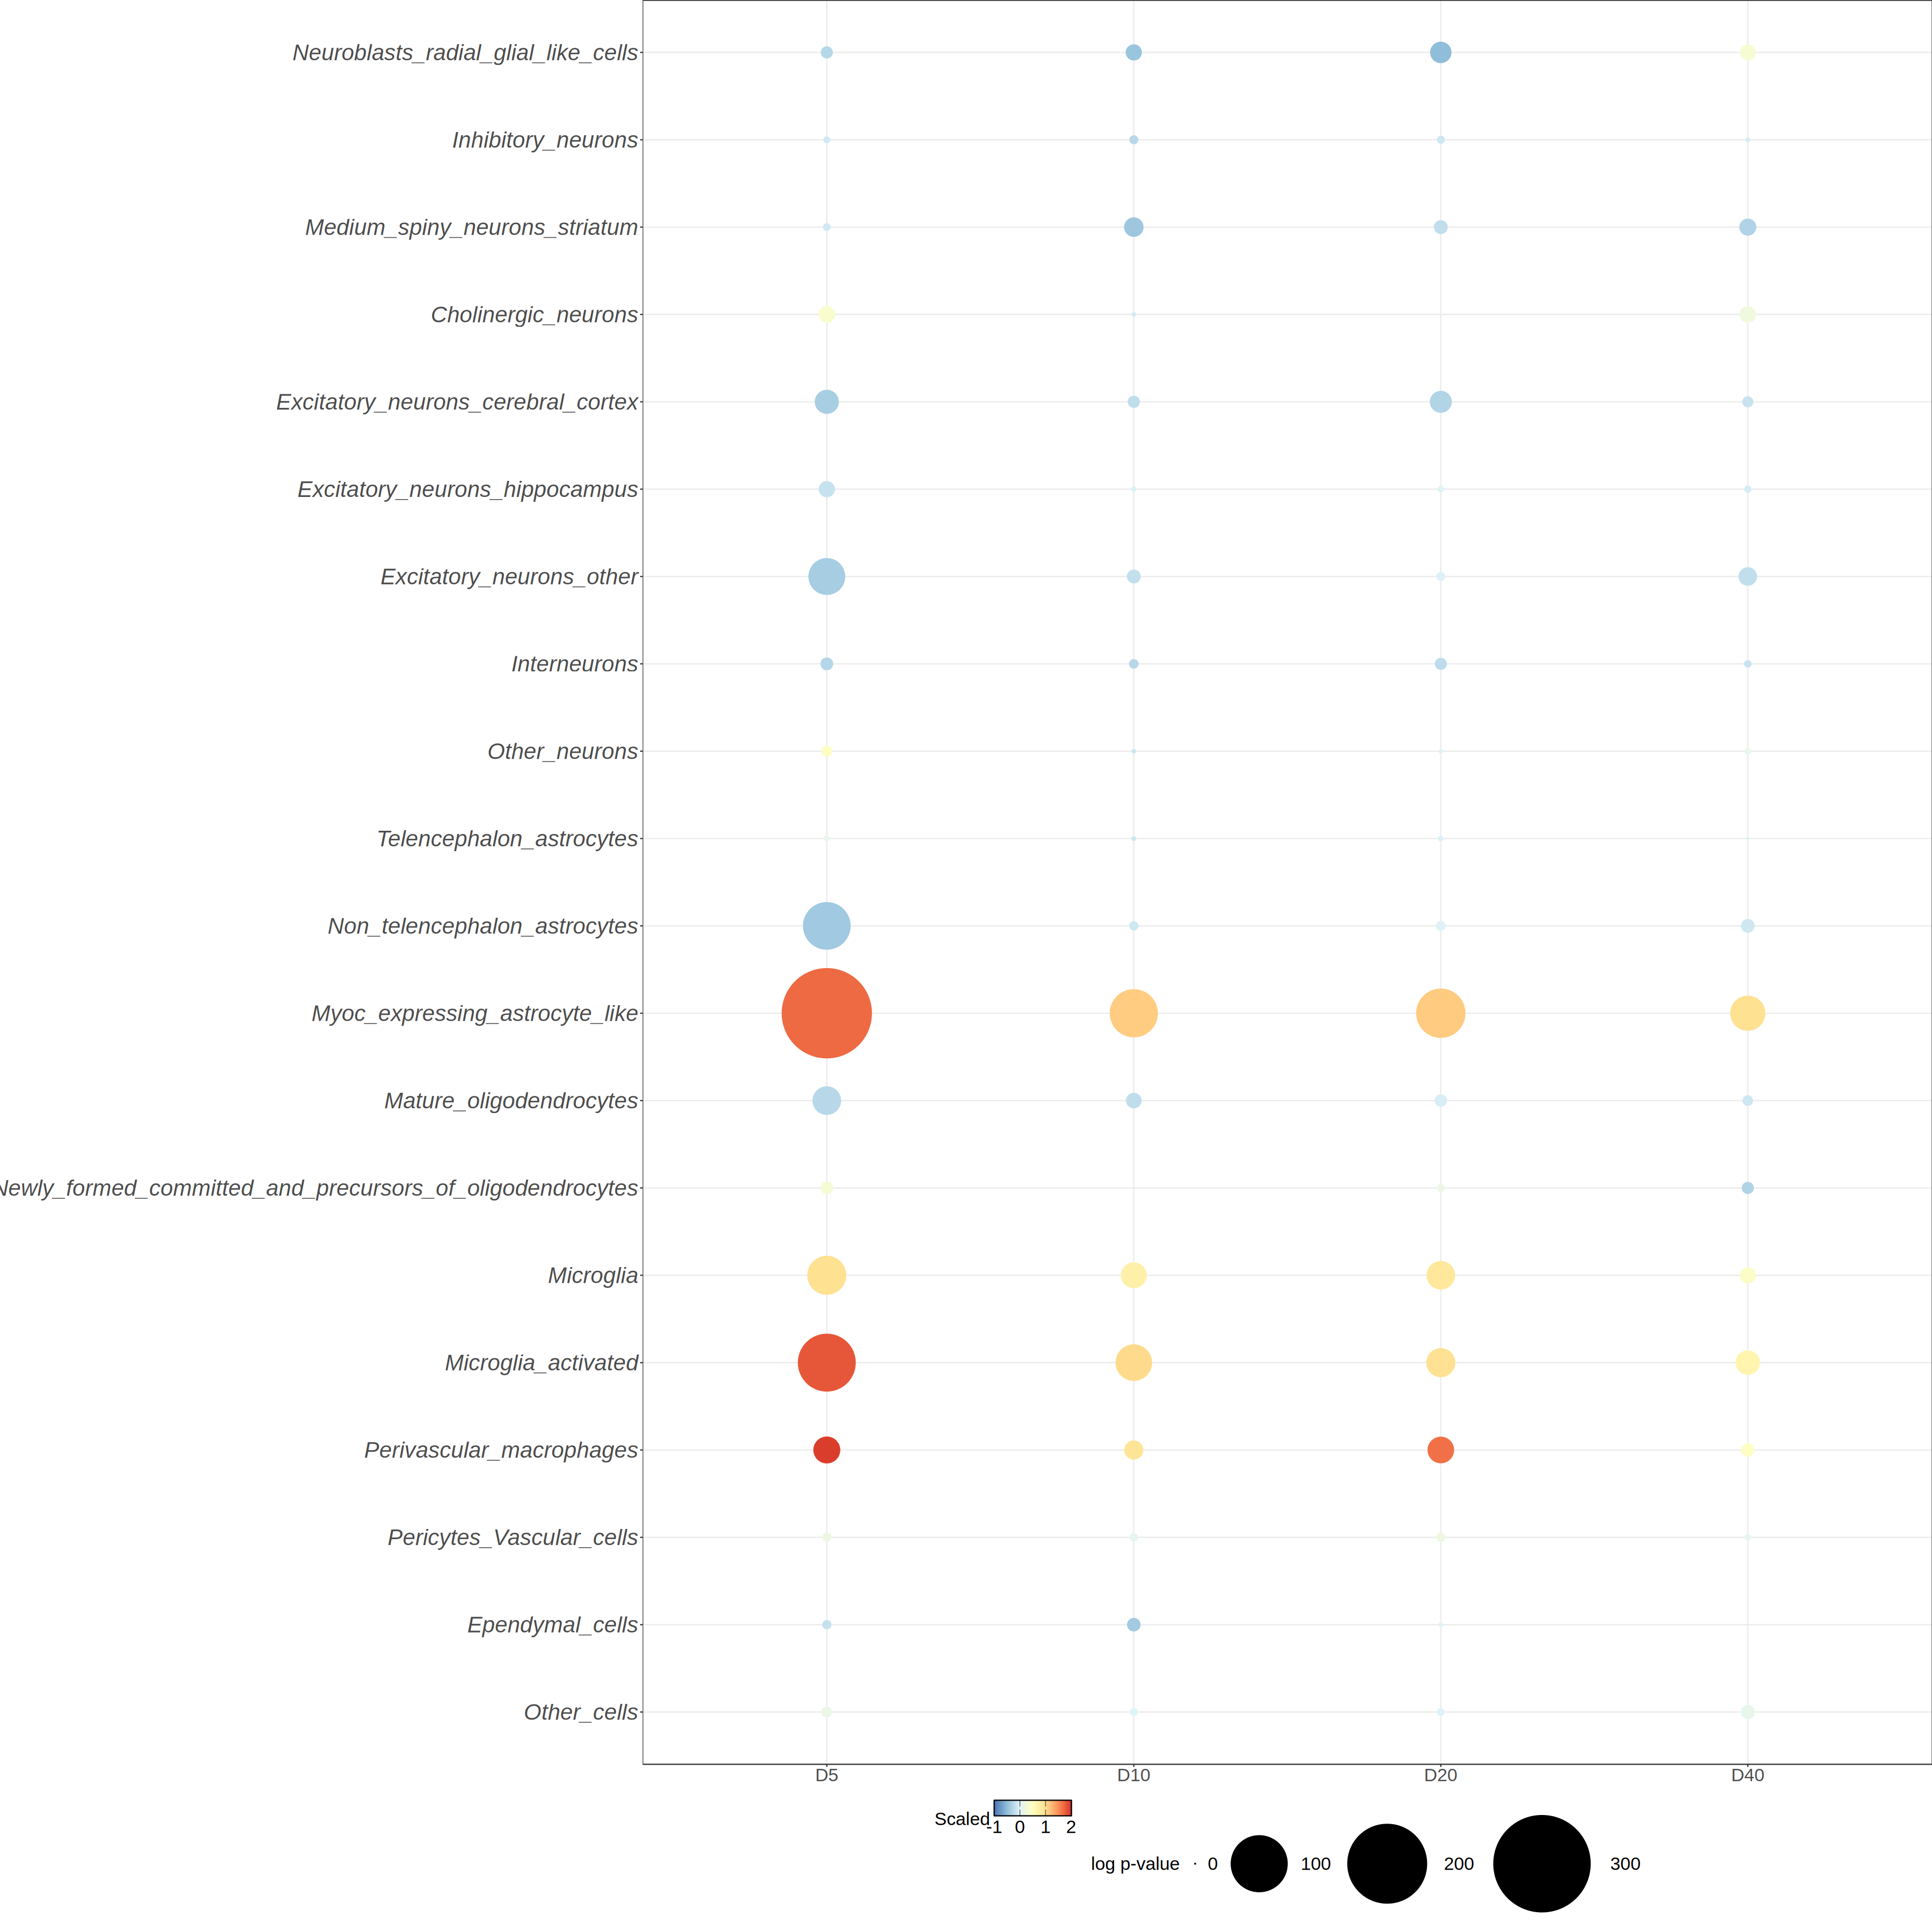

In [48]:
options(repr.plot.width = 30, repr.plot.height = 30, repr.plot.pointsize = 24)
dotplot <- left_join(
    result_FC,
    result %>%
    dplyr::select(id_to_merge, p_value),
    by = 'id_to_merge'
  ) %>%
  mutate(time = factor(time, levels = c("D5", "D10", "D20", "D40"))) %>%
  mutate(terms = factor(terms, levels = rev(colnames(table_class_by_clusters)))) %>%
  ggplot(aes(time, terms)) +
  geom_point(aes(color = FC, size = p_value)) +
  scale_color_distiller(
    palette = 'RdYlBu',
    direction = -1,
    name = 'Scaled',
    limits = c(-1, 2),
    guide = guide_colorbar(frame.colour = "black", ticks.colour = "black")
  ) +
  scale_size(name = 'log p-value', range = c(0,50), limits = c(0, 300)) +
  labs(y = 'Time', color = 'Expression') +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(size = 20),
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 20),
    legend.position = "bottom",
    axis.title.y = element_blank(),
    plot.margin = unit(c(0,0,0,0), "cm"),
    axis.text.y = element_text(size = 25, face = "italic")
  )

dotplot

In [49]:
ggsave(
  '/home/adufour/work/plots/epilepsie/dotplot_deconvolution_p_values.svg',
  dotplot,
  height = 30,
  width = 20
)

In [36]:
col_fun <- colorRamp2(seq(0.05, 0, length = 500), colorRampPalette(rev(brewer.pal(n = 10, name = "RdYlBu")))(500))
pdf('/home/adufour/work/plots/epilepsie/heatmap_deconvolution_p_values.pdf',width=40,height=80)
hm <- draw(ComplexHeatmap::Heatmap(result,
                                   col = col_fun,
                                   cluster_columns = FALSE,
                                   cluster_rows = FALSE,
                                   show_row_names = TRUE,
                                   show_column_names = TRUE,
                                   column_title = NULL), padding = unit(c(2, 2, 2, 10), "mm"))
dev.off()

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


pdf 
  2

In [42]:
colors_cells <- c(
  Inhibitory_neurons = '#ff8010',
  Cholinergic_neurons = '#0d5c78',
  Medium_spiny_neurons_striatum = '#ff88ad',
  Neuroblasts_radial_glial_like_cells = '#ffff00',
  Excitatory_neurons_cerebral_cortex = '#2ebce6',
  Excitatory_neurons_hippocampus = '#3c79bc',
  Excitatory_neurons_other = '#0C0CE6',
  Interneurons = '#0dccc7',
  Other_neurons = '#931110',
  Telencephalon_astrocytes = '#6a51a3',
  Non_telencephalon_astrocytes = '#3f007d',
  Myoc_expressing_astrocyte_like = '#ab1dff',
  Mature_oligodendrocytes = '#020302',
  Newly_formed_committed_and_precursors_of_oligodendrocytes = '#345247',
  Microglia = '#2eb934',
  Microglia_activated = '#67fa05',
  Perivascular_macrophages = '#709f6d',
  Pericytes_Vascular_cells = '#a87c70',
  Ependymal_cells = '#baa6a0',
  Other_cells = '#808080'
)


In [38]:
table_class_by_clusters$cluster <- rownames(table_class_by_clusters)

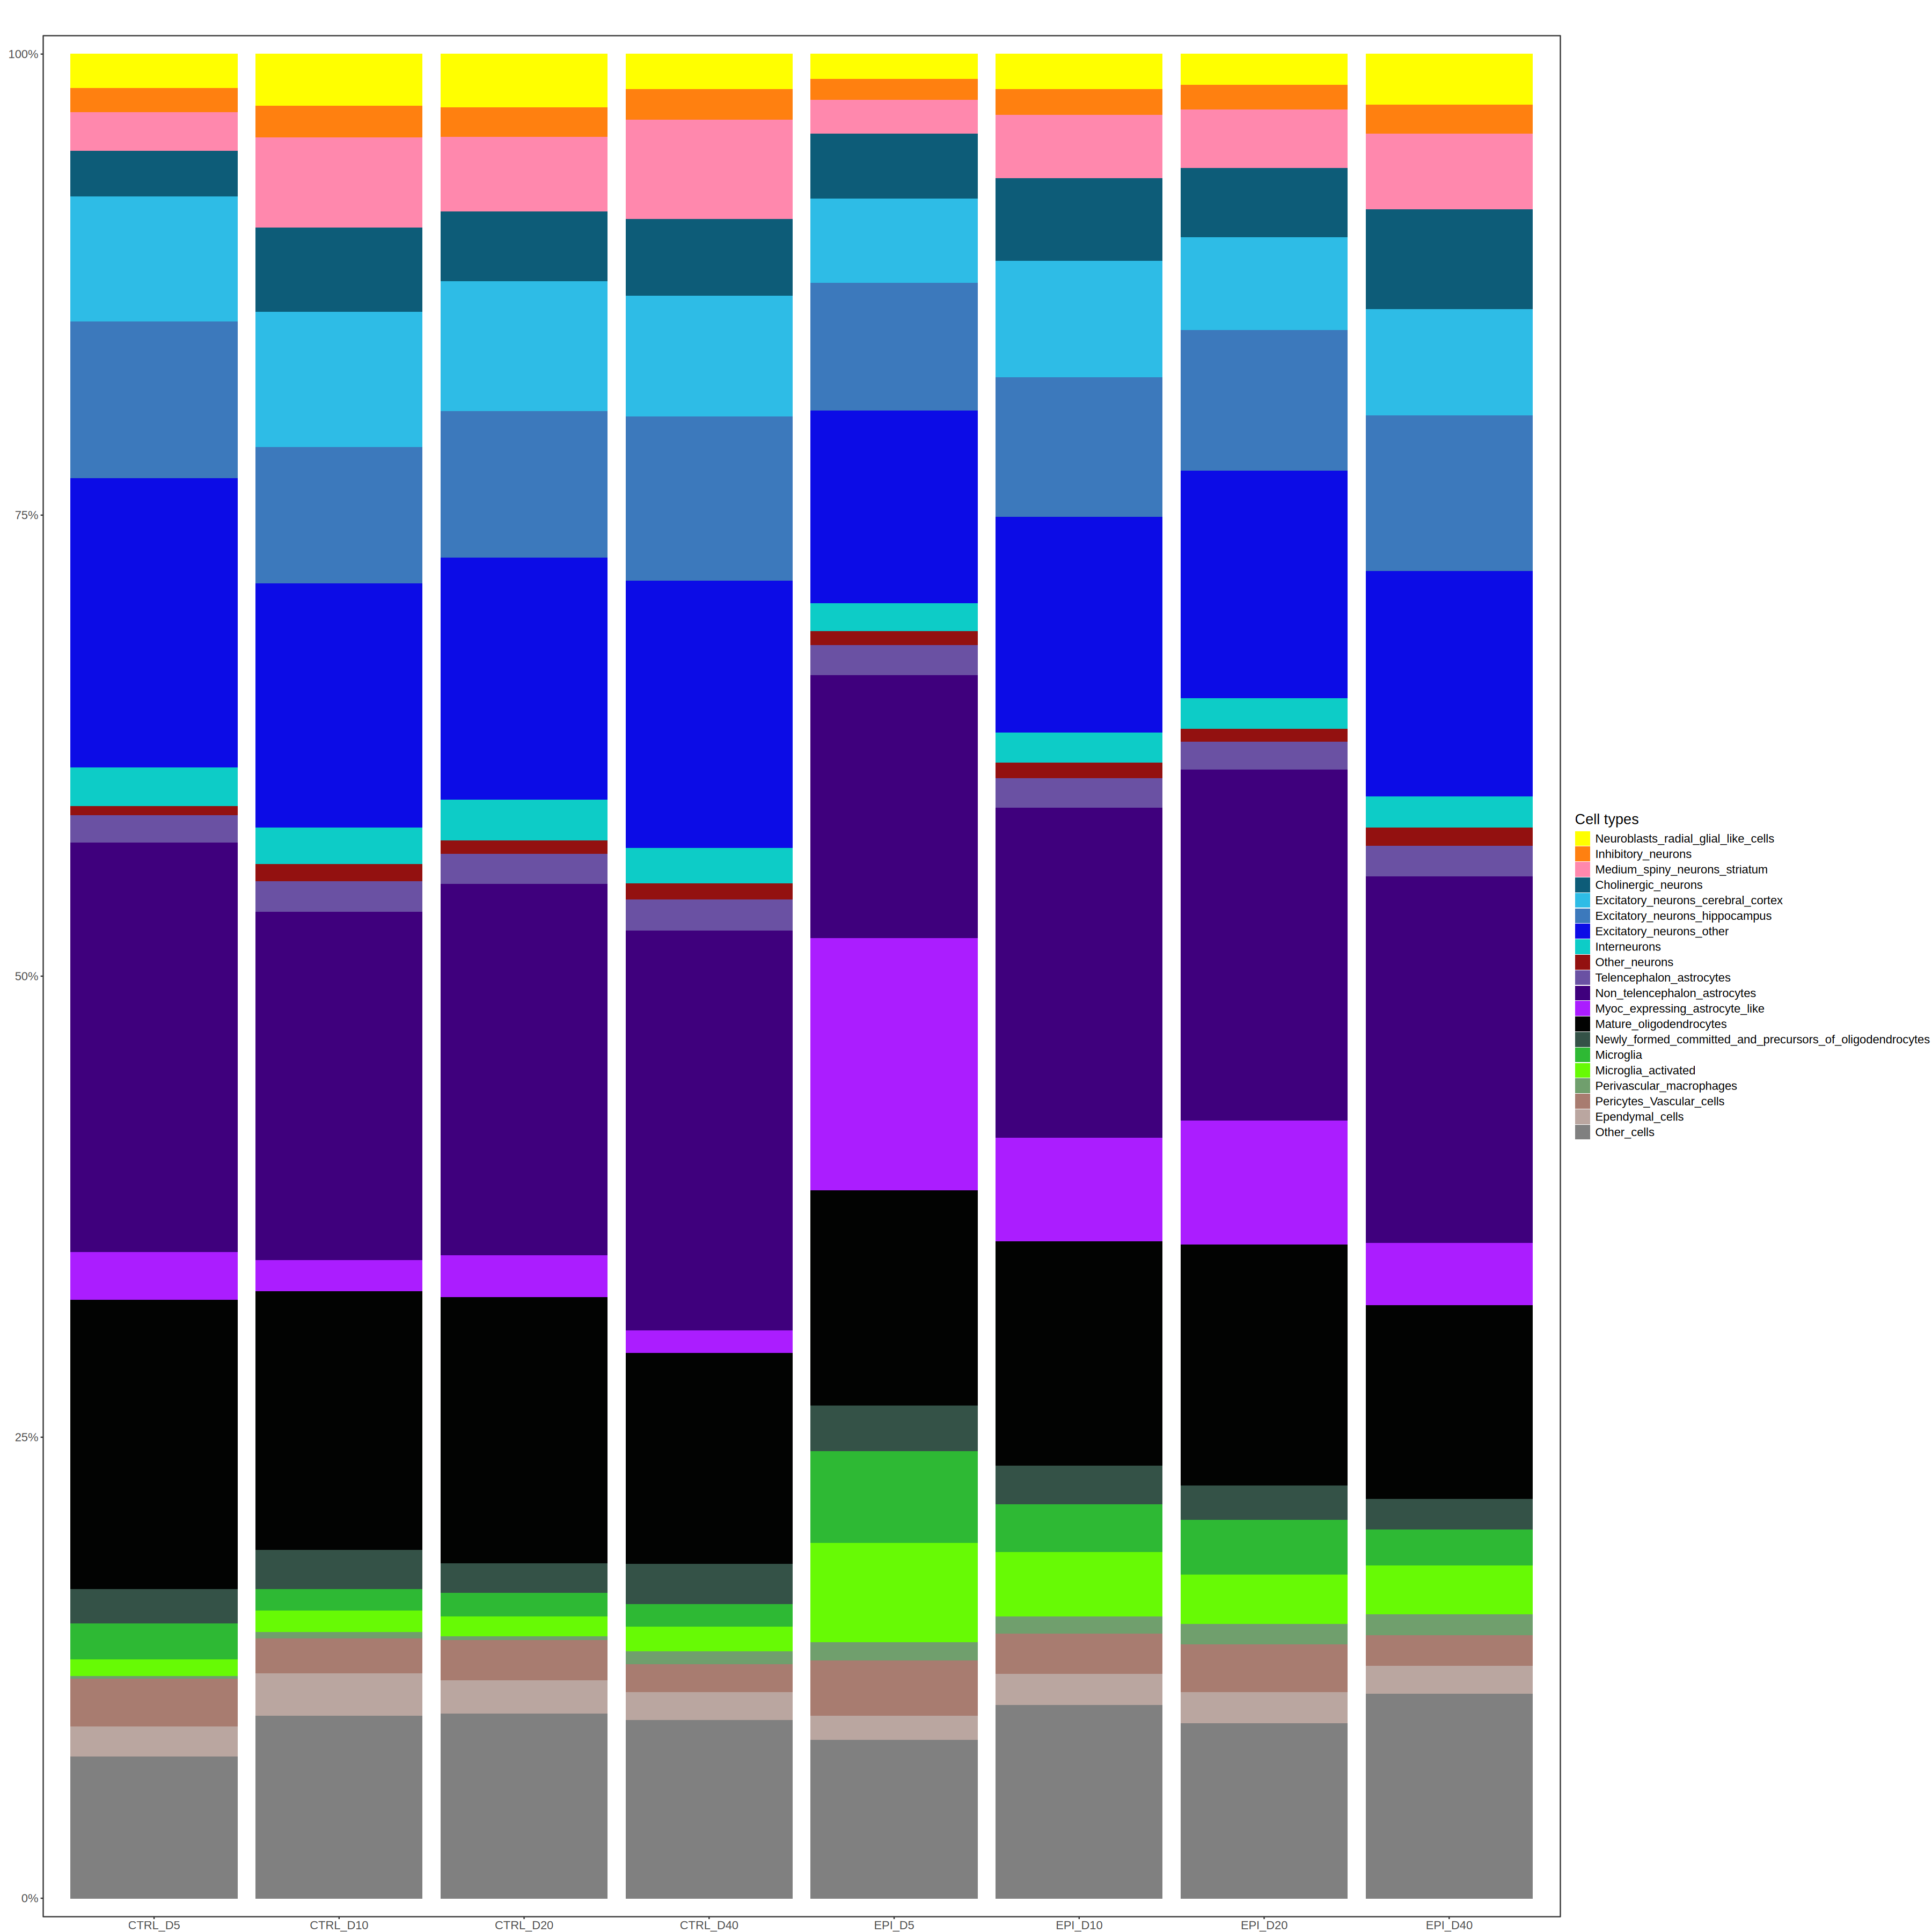

In [43]:
options(repr.plot.width = 30, repr.plot.height = 30, repr.plot.pointsize = 24)
barplot_sample <- table_class_by_clusters %>%
  reshape2::melt(id.vars = 'cluster') %>%
  mutate(cluster = factor(cluster, levels = c("CTRL_D5", "CTRL_D10", "CTRL_D20", "CTRL_D40", "EPI_D5", "EPI_D10", "EPI_D20", "EPI_D40"))) %>%
  ggplot(aes(cluster, value)) +
  geom_bar(aes(fill = variable), position = 'fill', stat = 'identity') +
  scale_fill_manual(name = 'Cell types', values = colors_cells) +
  scale_y_continuous(name = 'Percentage [%]', labels = scales::percent_format(), expand = c(0.01,0)) +
  coord_cartesian(clip = 'off') +
  theme_bw() +
  theme(
    legend.position = 'right',
    plot.title = element_text(hjust = 0.5),
    text = element_text(size = 16),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.title = element_blank(),
    plot.margin = margin(t = 40, r = 0, b = 0, l = 10, unit = 'pt')
  )

barplot_sample

In [44]:
ggsave(
  '/home/adufour/work/plots/epilepsie/barplot_cell_repartition.svg',
  barplot_sample,
  height = 18,
  width = 20
)